# CSHint Integration Tutorial
## Before you get started

### You need the following data:

**1) Reference proteomes for each species**

This model works right out of the box with refseq and ensemble proteome header formats from the following sources:
https://www.ncbi.nlm.nih.gov/datasets/
http://ftp.ensembl.org/pub/

if you are using data from one of these sources, download both the .faa and .gtf files. If not, the protomes input into the tool must be in the following format, with gene names that directly match those in the scRNA-seq matrices:

>\>gene_name_1
Sequence
>\>gene_name_2
Sequence

**2) Cleaned scRNA-seq matrices**

Counts should be stored within anndata objects compressed in the h5ad format. Raw counts should be stored in the adata.X slot. Each species should be stored in its own h5ad file. These datasets should be filtered for high quality genes/cells beforehand.

**3) Putative cell type annotations**
CSHint requires that each species have at least 3 cell types in common with the reference species. Cell type annotations do not need to be complete or highly granular. General groupings like "epithelial", "endothelial", "stromal", and "immune" will suffice. Cell type names need to be standardised across species. They should be stored in a single column in the adata.obs slot in the h5ads for each species.


## Preprocessing module

The preprocessing module is an optional module that automates some of the necessary preprocessing for CSHint. Note that these cleaning steps must be done manually if you choose note to use this module, or if your data does not follow standard formats.

### Step 1: clean the proteomes:

In the below step, we are cleaning the proteome headers so that they only contain gene names that match the scRNA-seq matrices. In this case, we are using proteome from both refseq and ensembl, to match the original assemblies used by the authors. The preprocess module can automatically detect these file headers, and parse them accordingly. It will write the cleaned fastas into a new directory

In [1]:
import warnings
from CSHint.utils.CSHint_preprocess import CSHint_preprocess
warnings.filterwarnings("ignore")

pre = CSHint_preprocess()

datapath = "../../PaperScripts/Spermatogenesis/Data/"
path_dict = {
    "chicken" : {"gtf" : datapath + "gtfs/chicken.gtf",
                 "fasta": datapath + "raw_proteomes/chicken.faa"},
    "human" : {"gtf" : datapath + "gtfs/human.gtf",
               "fasta": datapath + "raw_proteomes/human.faa"},
     "mouse" : {"gtf" : datapath + "gtfs/mouse.gtf",
                "fasta": datapath + "raw_proteomes/mouse.faa"},
     "Monodelphis" : {"gtf" : datapath + "gtfs/Monodelphis.gtf",
                      "fasta": datapath + "raw_proteomes/Monodelphis.faa"},
     "platypus" : {"gtf" : datapath + "gtfs/platypus.gtf",
                   "fasta": datapath + "raw_proteomes/platypus.faa"},
     "rhesus" : {"gtf" : datapath + "gtfs/rhesus.gff",
                 "fasta": datapath + "raw_proteomes/rhesus.faa"},
     "sheep" : {"gtf" : datapath + "gtfs/sheep.gtf",
                "fasta": datapath + "raw_proteomes/sheep.faa"}
}


pre.preprocess_fasta_headers(path_dict, out_dir ="filtered_proteomes")

[chicken] Converting FASTA headers... (detected format: ensembl)
  [chicken] GTF index (Ensembl): 93,251 accession entries.
  [chicken] Autodetected link field 'ENSGAL' (ENSGAL:200) from 200 headers.
  [chicken] 18308 unique symbols written (0 unmatched).
  [chicken] → filtered_proteomes/chicken.faa
  [chicken] → filtered_proteomes/chicken_id_map.csv
[human] Converting FASTA headers... (detected format: refseq)
  [human] GTF index (RefSeq): 212,424 accession entries.
  [human] Autodetected link field 'NP' (NP:200) from 200 headers.
  [human] 19869 unique symbols written (0 unmatched).
  [human] → filtered_proteomes/human.faa
  [human] → filtered_proteomes/human_id_map.csv
[mouse] Converting FASTA headers... (detected format: refseq)
  [mouse] GTF index (RefSeq): 101,433 accession entries.
  [mouse] Autodetected link field 'NP' (NP:200) from 200 headers.
  [mouse] 21847 unique symbols written (0 unmatched).
  [mouse] → filtered_proteomes/mouse.faa
  [mouse] → filtered_proteomes/mouse_id

### Step 2: Synchronising the protomes and the scRNA-seq.

The following function filters the protome and the scRNA data so that only genes shared between the two are kept for each species. This technically isn't required, however it is HIGHLY recommended to do this to cut down on run times down the line.

In [2]:
path_dict = {
    "chicken" : {"h5ad" : datapath + "raw_adatas/chicken.h5ad",
                 "fasta": "filtered_proteomes/chicken.faa"},
    "human" : {"h5ad" : datapath + "raw_adatas/human.h5ad",
               "fasta": "filtered_proteomes/human.faa"},
     "mouse" : {"h5ad" : datapath + "raw_adatas/mouse.h5ad",
                "fasta": "filtered_proteomes/mouse.faa"},
     "Monodelphis" : {"h5ad" : datapath + "raw_adatas/Monodelphis.h5ad",
                      "fasta": "filtered_proteomes/Monodelphis.faa"},
     "platypus" : {"h5ad" : datapath + "raw_adatas/platypus.h5ad",
                   "fasta": "filtered_proteomes/platypus.faa"},
     "rhesus" : {"h5ad" : datapath + "raw_adatas/rhesus.h5ad",
                 "fasta": "filtered_proteomes/rhesus.faa"},
     "sheep" : {"h5ad" : datapath + "raw_adatas/sheep.h5ad",
                "fasta": "filtered_proteomes/sheep.faa"}
}

pre.synchronize_scrna_and_proteomes(species_map = path_dict, prot_out_dir="filtered_proteomes/", scrna_out_dir="filtered_scrna/")

[chicken] Harmonizing scRNA-seq and Proteome...
  [chicken] Shared genes found: 9207
  [chicken] Saved filtered h5ad to filtered_scrna/chicken.h5ad
  [chicken] Saved filtered proteome to filtered_proteomes/chicken.faa
[human] Harmonizing scRNA-seq and Proteome...
  [human] Shared genes found: 17454
  [human] Saved filtered h5ad to filtered_scrna/human.h5ad
  [human] Saved filtered proteome to filtered_proteomes/human.faa
[mouse] Harmonizing scRNA-seq and Proteome...
  [mouse] Shared genes found: 18629
  [mouse] Saved filtered h5ad to filtered_scrna/mouse.h5ad
  [mouse] Saved filtered proteome to filtered_proteomes/mouse.faa
[Monodelphis] Harmonizing scRNA-seq and Proteome...
  [Monodelphis] Shared genes found: 10498
  [Monodelphis] Saved filtered h5ad to filtered_scrna/Monodelphis.h5ad
  [Monodelphis] Saved filtered proteome to filtered_proteomes/Monodelphis.faa
[platypus] Harmonizing scRNA-seq and Proteome...
  [platypus] Shared genes found: 8938
  [platypus] Saved filtered h5ad to fi

## Running Orthofinder
CSHint requires gene family information. It does this by using orthogroup information from Orthofinder (https://doi.org/10.1186/s13059-019-1832-y). This module comes with a python wrapper for it:

In [3]:
from CSHint.utils.OrthofinderWrapper import OrthoFinderWrapper
ow = OrthoFinderWrapper()
ow.run_orthofinder(inputdir="filtered_proteomes/",
    orthofinder_path="orthofinder",
    threads=16)

Running: orthofinder -f filtered_proteomes/ -t 16

OrthoFinder version 3.0.1b1 Copyright (C) 2014 David Emms

2026-08-31 07:04:08 : Starting OrthoFinder 3.0.1b1
16 thread(s) for highly parallel tasks (BLAST searches etc.)
2 thread(s) for OrthoFinder algorithm

Results directory: /storage/shared/alicia/analysis/CSHInt_github/Docs/source/filtered_proteomes/OrthoFinder/Results_Aug31_1/

Checking required programs are installed
----------------------------------------
Running with the recommended MSA tree inference by default. To revert to legacy method use '-M dendroblast'.

Test can run "mcl -h" - ok
Test can run "mafft" - ok
Test can run "fasttree" - ok

Monodelphis_id_map.csv
chicken_id_map.csv
human_id_map.csv
mouse_id_map.csv
platypus_id_map.csv
rhesus_id_map.csv
sheep_id_map.csv
OrthoFinder expects FASTA files to have one of the following extensions: fa, fas, fasta, pep, faa

Dividing up work for BLAST for parallel processing
--------------------------------------------------
2026-0

## Running the count merge module
The countmerge module merges counts together by creating 1-1 pairings of genes across species based on both sequence and expression level orthology using a greedy algorithm. TODO: EXPAND ON HOW THIS WORKS HERE

In [4]:
from CSHint.utils.CSHint_merger import CSHint_merger

scrnadirs = {
    "human": "filtered_scrna/human.h5ad",
    "mouse": "filtered_scrna/mouse.h5ad",
    "rhesus": "filtered_scrna/rhesus.h5ad",
    "sheep" : "filtered_scrna/sheep.h5ad",
    "Monodelphis": "filtered_scrna/Monodelphis.h5ad",
    "platypus": "filtered_scrna/platypus.h5ad",
    "chicken": "filtered_scrna/chicken.h5ad"

}

merger = CSHint_merger(
    orthofinder_resultdir="filtered_proteomes/OrthoFinder/Results_Aug31/",
    scrna_dirs=scrnadirs,
    output_dir="merged_output/",
    annotation_obs_col = "metacluster", #include the name of the column you put the cell type annotations in here

)

merger.run()

Loading OrthoFinder results...
Loading scRNA-seq data...
  Loading human...
  Loading mouse...
  Loading rhesus...
  Loading sheep...
  Loading Monodelphis...
  Loading platypus...
  Loading chicken...
  Found 5 anchor cell types across all species
Computing anchor cell type means (normalised)...
Computing greedy functional homolog layering...
Filling final matrix...
  24394 rows x 38825 cells; 95.7% of total counts retained in orthogroup layers
Normalising (scale_factor=10000, log1p=True, by=matrix)...
Saving to merged_output/...
Saved 24394 rows and 38825 cells.
Metadata generated: metadata.txt, rowmetadata.csv, normalisation.json
Matrices: matrix.mtx (raw counts), matrix_normalised.mtx (scaled)


## Running the integration module

Now that we have the merged matrix, we can begin the integration steps. First, we need to create a select set of features for integration (this is comparable to running sc.pp.highly_variable_genes() in scanpy or FindVariableFeatures in seurat). For feature selection, it is best to prioritise genes that will have similar expression patterns across cell types and  preserve enough variance to distinguish cell types. Do do this, CSHint uses a two part filter. The discriminability percentile is a measure of a features variance (for measuring it's capacity for cell type separation) and the conservation threshold measures how similar a features expression is across species. These two thresholds can be manually adjusted. It is recommended to leave around 1000 features for integration.

In [10]:
from CSHint.utils.CSHint_integration import CSHint_integration
analysis = CSHint_integration("merged_output/", reference_species ="human")
analysis.load()

analysis.select_features(
    discriminability_threshold=0.4,
    conservation_threshold=0.5,
)



Loading data from merged_output/...
Calculating cell type means from matrix...


/storage/shared/alicia/analysis/CSHInt_github/CSHint/utils/CSHint_integration.py:209: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  final_candidates.append(feat)


Selected 1760 features.


Next, we can prepare the selected features for integration. This step normalises the data and notes equivalencies across cell types.

In [11]:
adata = analysis.prepare_for_integration()

/home/apetrany/miniconda3/envs/CSHint/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


  Reference species: human (7 cell types)
  Full anchors (all species): 5
  Partial anchors: 2
  Unique cell types: 0
  human <-> mouse: 7 shared cell types (Early Sperm, Early Spermatid, Early Spermatocyte, Late Sperm, Late Spermatid...)
  human <-> rhesus: 5 shared cell types (Early Spermatid, Early Spermatocyte, Late Spermatid, Late Spermatocyte, SSC)
  human <-> sheep: 7 shared cell types (Early Sperm, Early Spermatid, Early Spermatocyte, Late Sperm, Late Spermatid...)
  human <-> Monodelphis: 6 shared cell types (Early Spermatid, Early Spermatocyte, Late Sperm, Late Spermatid, Late Spermatocyte...)
  human <-> platypus: 5 shared cell types (Early Spermatid, Early Spermatocyte, Late Spermatid, Late Spermatocyte, SSC)
  human <-> chicken: 6 shared cell types (Early Spermatid, Early Spermatocyte, Late Sperm, Late Spermatid, Late Spermatocyte...)


Now we can run a brief optimisation protocol to identify the optimal number of anchors for integration. Benchmark evaluation showed that there was minimal performance gain after 10 trials.


At this stage, it is very important to consider whether you would like anchor selection to be cell type aware or cell type agnostic. If you choose cell type aware, anchors will be restricted between cells of the same type. This approach is optimal if you have high quality cell annotations. If the cell type annotations are poor quality or incomplete, run the model with cell_type_agnostic = True.


In [12]:
adata, study, best_params = analysis.integrate(
    adata,
    n_trials=15,
    cell_type_agnostic=False
)

  Precomputing anchor candidates...
  Running cell-type-aware anchor selection: human <-> mouse (7 shared types)
  human x mouse: 7180 candidates across 7 shared cell types | weight range: [0.300, 0.557]
  Running cell-type-aware anchor selection: human <-> rhesus (5 shared types)
  human x rhesus: 31148 candidates across 5 shared cell types | weight range: [0.300, 0.674]
  Running cell-type-aware anchor selection: human <-> sheep (7 shared types)
  human x sheep: 11921 candidates across 7 shared cell types | weight range: [0.300, 0.560]
  Running cell-type-aware anchor selection: human <-> Monodelphis (6 shared types)
  human x Monodelphis: 14252 candidates across 6 shared cell types | weight range: [0.300, 0.571]
  Running cell-type-aware anchor selection: human <-> platypus (5 shared types)
  human x platypus: 14308 candidates across 5 shared cell types | weight range: [0.300, 0.565]
  Running cell-type-aware anchor selection: human <-> chicken (6 shared types)
  human x chicken: 12

  0%|          | 0/15 [00:00<?, ?it/s]

  mouse: 530 anchors | mean weight: 0.368
  rhesus: 530 anchors | mean weight: 0.412
  sheep: 530 anchors | mean weight: 0.361
  Monodelphis: 530 anchors | mean weight: 0.379
  platypus: 530 anchors | mean weight: 0.405
  chicken: 530 anchors | mean weight: 0.389
  3180 total anchors across 6 species pairs
  Fitting TPS correction (3180 control points)...
  Fitting TPS for mouse (530 control points)...
    Mean post-correction distance to target: 0.1778
  Fitting TPS for rhesus (530 control points)...
    Mean post-correction distance to target: 0.2595
  Fitting TPS for sheep (530 control points)...
    Mean post-correction distance to target: 0.2087
  Fitting TPS for Monodelphis (530 control points)...
    Mean post-correction distance to target: 0.2862
  Fitting TPS for platypus (530 control points)...
    Mean post-correction distance to target: 0.3129
  Fitting TPS for chicken (530 control points)...
    Mean post-correction distance to target: 0.2803
  TPS correction complete


/home/apetrany/miniconda3/envs/CSHint/lib/python3.10/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/apetrany/miniconda3/envs/CSHint/lib/python3.10/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/apetrany/miniconda3/envs/CSHint/lib/python3.10/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/apetrany/miniconda3/envs/CSHint/lib/python3.10/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future 

  mouse: only 736 anchors available (requested 1331)
  mouse: 736 anchors | mean weight: 0.352
  rhesus: only 972 anchors available (requested 1331)
  rhesus: 972 anchors | mean weight: 0.372
  sheep: only 579 anchors available (requested 1331)
  sheep: 579 anchors | mean weight: 0.356
  Monodelphis: only 663 anchors available (requested 1331)
  Monodelphis: 663 anchors | mean weight: 0.365
  platypus: only 1020 anchors available (requested 1331)
  platypus: 1020 anchors | mean weight: 0.367
  chicken: only 734 anchors available (requested 1331)
  chicken: 734 anchors | mean weight: 0.368
  4704 total anchors across 6 species pairs
  Fitting TPS correction (4704 control points)...
  Fitting TPS for mouse (736 control points)...
    Mean post-correction distance to target: 0.1998
  Fitting TPS for rhesus (972 control points)...
    Mean post-correction distance to target: 0.3088
  Fitting TPS for sheep (579 control points)...
    Mean post-correction distance to target: 0.2161
  Fitting

...

  mouse: only 736 anchors available (requested 812)
  mouse: 736 anchors | mean weight: 0.352
  rhesus: 812 anchors | mean weight: 0.385
  sheep: only 579 anchors available (requested 812)
  sheep: 579 anchors | mean weight: 0.356
  Monodelphis: only 663 anchors available (requested 812)
  Monodelphis: 663 anchors | mean weight: 0.365
  platypus: 812 anchors | mean weight: 0.382
  chicken: only 734 anchors available (requested 812)
  chicken: 734 anchors | mean weight: 0.368
  4336 total anchors across 6 species pairs
  Fitting TPS correction (4336 control points)...
  Fitting TPS for mouse (736 control points)...
    Mean post-correction distance to target: 0.1998
  Fitting TPS for rhesus (812 control points)...
    Mean post-correction distance to target: 0.3013
  Fitting TPS for sheep (579 control points)...
    Mean post-correction distance to target: 0.2161
  Fitting TPS for Monodelphis (663 control points)...
    Mean post-correction distance to target: 0.3092
  Fitting TPS for p

/home/apetrany/miniconda3/envs/CSHint/lib/python3.10/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/apetrany/miniconda3/envs/CSHint/lib/python3.10/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/apetrany/miniconda3/envs/CSHint/lib/python3.10/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/apetrany/miniconda3/envs/CSHint/lib/python3.10/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future 

  mouse: 396 anchors | mean weight: 0.381
  rhesus: 396 anchors | mean weight: 0.430
  sheep: 396 anchors | mean weight: 0.376
  Monodelphis: 396 anchors | mean weight: 0.396
  platypus: 396 anchors | mean weight: 0.419
  chicken: 396 anchors | mean weight: 0.407
  2376 total anchors across 6 species pairs
  Fitting TPS correction (2376 control points)...
  Fitting TPS for mouse (396 control points)...
    Mean post-correction distance to target: 0.1581
  Fitting TPS for rhesus (396 control points)...
    Mean post-correction distance to target: 0.2411
  Fitting TPS for sheep (396 control points)...
    Mean post-correction distance to target: 0.1848
  Fitting TPS for Monodelphis (396 control points)...
    Mean post-correction distance to target: 0.2653
  Fitting TPS for platypus (396 control points)...
    Mean post-correction distance to target: 0.2778
  Fitting TPS for chicken (396 control points)...
    Mean post-correction distance to target: 0.2495
  TPS correction complete


/home/apetrany/miniconda3/envs/CSHint/lib/python3.10/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/apetrany/miniconda3/envs/CSHint/lib/python3.10/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/apetrany/miniconda3/envs/CSHint/lib/python3.10/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/apetrany/miniconda3/envs/CSHint/lib/python3.10/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future 


  Best weighted score: 0.6817
  Best params:         {'n_anchors_target': 845}
  n_anchors:           4402
  Individual scores:   {'ari': 0.4166, 'nmi': 0.6007, 'graph_connectivity': 0.9874}

  Refitting with best parameters...
  mouse: only 736 anchors available (requested 845)
  mouse: 736 anchors | mean weight: 0.352
  rhesus: 845 anchors | mean weight: 0.382
  sheep: only 579 anchors available (requested 845)
  sheep: 579 anchors | mean weight: 0.356
  Monodelphis: only 663 anchors available (requested 845)
  Monodelphis: 663 anchors | mean weight: 0.365
  platypus: 845 anchors | mean weight: 0.379
  chicken: only 734 anchors available (requested 845)
  chicken: 734 anchors | mean weight: 0.368
  4402 total anchors across 6 species pairs
  Fitting TPS correction (4402 control points)...
  Fitting TPS for mouse (736 control points)...
    Mean post-correction distance to target: 0.1998
  Fitting TPS for rhesus (845 control points)...
    Mean post-correction distance to target: 0.3

We can find the final embeddings here:

In [14]:
adata.obsm["X_pca_tps"]

array([[-7.28609276e+00,  1.66856232e+01,  1.44719458e+01, ...,
        -1.08617330e+00,  1.07223773e+00,  5.56654811e-01],
       [-1.18246851e+01,  4.42361736e+00,  9.45664310e+00, ...,
        -1.31003475e+00, -3.08465660e-01, -5.72718143e-01],
       [-1.10534458e+01,  5.66070271e+00,  1.31512051e+01, ...,
        -1.10106695e+00, -4.37325567e-01, -3.49255025e-01],
       ...,
       [-8.19804764e+00,  8.10736084e+00,  1.26852741e+01, ...,
         1.55204010e+00, -1.20766544e+00, -5.01220703e-01],
       [-1.20164642e+01,  5.28601837e+00,  1.01638737e+01, ...,
         1.79658985e+00,  1.02914333e-01, -1.14043474e-01],
       [-1.71755562e+01,  6.77668190e+00,  9.49584961e+00, ...,
         1.19258976e+00, -6.86836243e-03, -2.40212917e-01]],
      shape=(38825, 50), dtype=float32)

Now, we can check out the umap:

In [15]:
import scanpy as sc
sc.pp.neighbors(adata)
sc.tl.umap(adata)

/home/apetrany/miniconda3/envs/CSHint/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


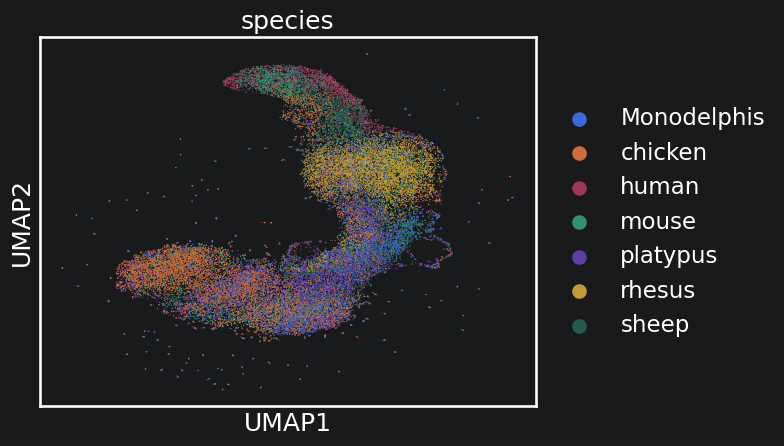

In [16]:
sc.pl.umap(adata, color= "species")

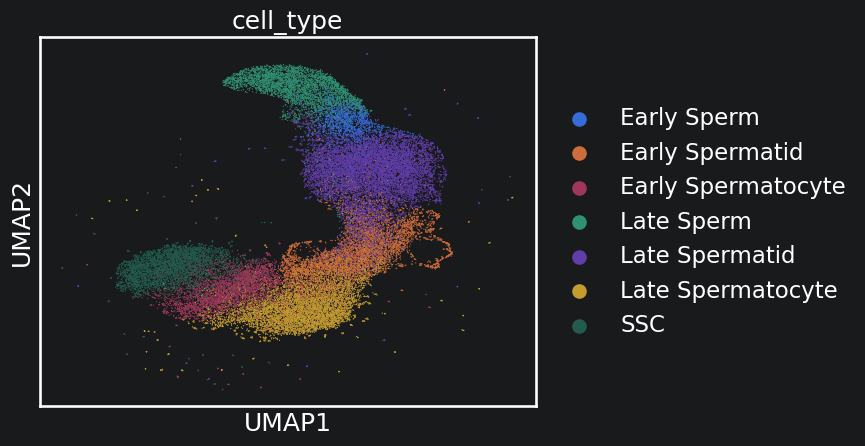

In [17]:
sc.pl.umap(adata, color = "cell_type")

Sometimes, you may notice cells that appeared to integrate poorly. These manifest a cells that are not close to their cell-type cluster of origin. This may happen if a cell was not properly labeled or if it's a doublet. These cells can be easily filtered out with the following command:


In [27]:
adata_pcacor = analysis.post_integration_correction(adata, ["cell_type", "species"], method = "pca", pval_cutoff = pow(10, -5))

Skipping ('Early Spermatid', 'chicken'): only 185 cells (need 250)
Skipping ('Early Spermatocyte', 'rhesus'): only 188 cells (need 250)
Skipping ('Late Sperm', 'Monodelphis'): only 74 cells (need 250)
Skipping ('SSC', 'Monodelphis'): only 168 cells (need 250)
Skipping ('SSC', 'sheep'): only 86 cells (need 250)
Removing 9407 / 38825 cells (24.2%)


Now we can see that they're gone!

/home/apetrany/miniconda3/envs/CSHint/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


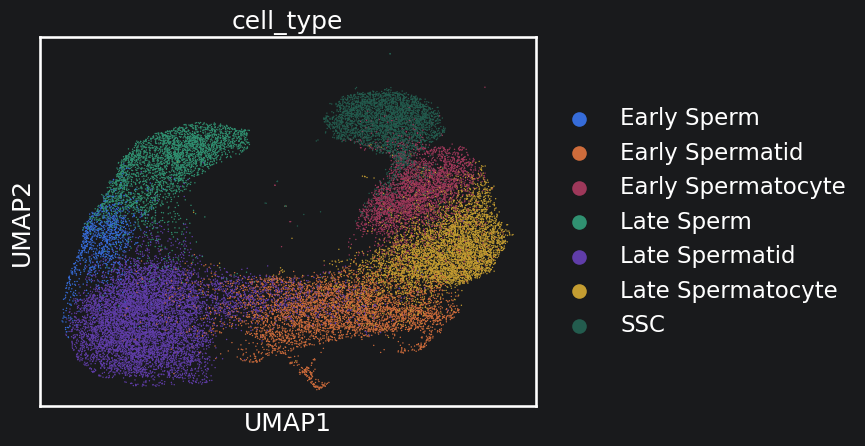

In [31]:
sc.tl.umap(adata_pcacor, random_state=1)
sc.pl.umap(adata_pcacor, color = "cell_type")

Thats it! Now we can save out the embeddings. They are stored in adata.obsm["X_pca"]. In any downstream analysis that you may do, you can sub the merged CSHint embeddings for PCA embeddings.

In [20]:
import pandas as pd
pca_df = pd.DataFrame(
    adata_pcacor.obsm["X_pca"],
    index=adata_pcacor.obs_names  # cell names
)
pca_df.to_csv("embeddings.csv")

adata_pcacor.obs.to_csv("metadata.csv")

adata_pcacor.write_h5ad("adata.h5ad")